In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
df = pd.read_csv(r"C:\Users\ahmed\Desktop\cleaned_dataset.csv")

In [7]:
df.shape

(520, 17)

In [9]:
y = df['price']
x = df.drop(columns = ['price'])

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
#preprocessing
# Separate numeric and categorical features
numeric_features = x.select_dtypes(include=['int64','float64']).columns
categorical_features = x.select_dtypes(include=['object']).columns

# Transformers
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocess', preprocessor),
                           ('model', model)])
    pipe.fit(x_train, y_train)
    preds = pipe.predict(x_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)   
    r2 = r2_score(y_test, preds)
    
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results)
print(results_df)

               Model           MAE          RMSE        R2
0  Linear Regression  2.754390e+06  3.259870e+06 -0.013093
1      Random Forest  2.838911e+06  3.409060e+06 -0.107945
2  Gradient Boosting  2.827828e+06  3.387129e+06 -0.093736


In [35]:
# Save cleaned dataset
df.to_csv("cleaned_dataset_final.csv", index=False)

# Save trained models
import joblib
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocess', preprocessor),
                           ('model', model)])
    pipe.fit(x, y)
    joblib.dump(pipe, f"{name}.joblib")

In [41]:
# Example: test Random Forest
rf_preds = models["Random Forest"].fit(x_train, y_train).predict(x_test)

# Example: test Linear Regression
lr_preds = models["Linear Regression"].fit(x_train, y_train).predict(x_test)

# Example: test Gradient Boosting
gb_preds = models["Gradient Boosting"].fit(x_train, y_train).predict(x_test)

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")

# Test each model
evaluate_model(y_test, rf_preds, "Random Forest")
evaluate_model(y_test, lr_preds, "Linear Regression")
evaluate_model(y_test, gb_preds, "Gradient Boosting")

Random Forest → MAE: 2838102.20, RMSE: 3407060.41, R²: -0.107
Linear Regression → MAE: 2754389.98, RMSE: 3259869.75, R²: -0.013
Gradient Boosting → MAE: 2827827.91, RMSE: 3387128.58, R²: -0.094


C:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [47]:
results = {
    "Random Forest": [mean_absolute_error(y_test, rf_preds),
                      mean_squared_error(y_test, rf_preds, squared=False),
                      r2_score(y_test, rf_preds)],
    "Linear Regression": [mean_absolute_error(y_test, lr_preds),
                          mean_squared_error(y_test, lr_preds, squared=False),
                          r2_score(y_test, lr_preds)],
    "Gradient Boosting": [mean_absolute_error(y_test, gb_preds),
                          mean_squared_error(y_test, gb_preds, squared=False),
                          r2_score(y_test, gb_preds)]
}

results_df = pd.DataFrame(results, index=["MAE","RMSE","R²"]).T
print(results_df)

                            MAE          RMSE        R²
Random Forest      2.838102e+06  3.407060e+06 -0.106646
Linear Regression  2.754390e+06  3.259870e+06 -0.013093
Gradient Boosting  2.827828e+06  3.387129e+06 -0.093736


C:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


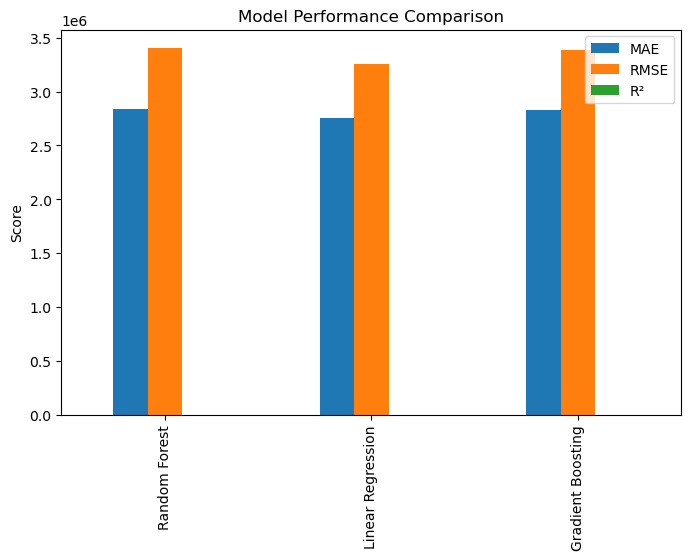

In [49]:
results_df.plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()